# 06 — How does treatment affect SPP1-TAMs *in tissue*?

The condition-aware layer over 02-04. Those notebooks answer *where* SPP1-TAMs sit; this one
answers *how treatment changes them*, using the full design rather than the coarse
`no_RT / RT_direct / RT_abscopal` grouping they currently carry.

### What this adds that 02-04 do not have
1. **A CAR-T specificity axis.** 02-04 only know whether a tissue was irradiated. They cannot
   compare **PSCA-specific vs TAG72 non-specific** CAR-T — which 05 showed is one of the
   cleanest signals in the single-cell data (~40% Spp1 reduction, largest M1 skew).
2. **Within-mouse pairing.** Spatial tissues are named `<cond>_<loc>_<rep>`, so `X_1_2` and
   `X_2_2` are two tumours from **one animal**. Tu1-vs-Tu2 is therefore paired — far more
   sensitive at n=3, and the cleanest spatial statement of the abscopal effect.
3. **Absolute burden, not just fractions.** TAMs per mm² of tissue (convex-hull area), so
   "more SPP1-TAMs" can be distinguished from "fewer of everything else".
4. **Recruitment vs state.** `mac_density` (how many macrophages) and `mean_sig` (how SPP1-TAM
   each one is) move independently. Reporting both separates *more macs arrived* from *the same
   macs changed program* — the same decomposition 05 §5 did in single-cell, and the difference
   between a trafficking story and a reprogramming story.
5. **Treatment x niche and treatment x neighbourhood interactions**, by re-reading the long CSVs
   02 and 03 already wrote — no recomputation.

**Run 02 and 03 first.** §7 and §8 read their outputs; the rest of the notebook works without them.

In [1]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

import scanpy as sc
import spatialdata as spd

from scipy.stats import mannwhitneyu
from scipy.spatial import ConvexHull

try:
    from spatialdata.transformations import get_transformation
except Exception:
    get_transformation = None

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80); pd.set_option("display.width", 240)

/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


## 1. Config — the design, encoded as attributes

In [ ]:
PROJ_DIR  = Path("/coh_labs/yunroseli/Jona/CAR-T")
ZARR_FILE = PROJ_DIR / "data/zarr/fullDataset/processing_Zarr/1_C2l_annotated_CC"
OUT_DIR   = PROJ_DIR / "results/spp1_analysis"
FIG_DIR   = OUT_DIR / "figures"
SIG_CSV   = OUT_DIR / "sc_spp1_tam_signature.csv"        # written by 01c §5
OUT_DIR.mkdir(parents=True, exist_ok=True); FIG_DIR.mkdir(parents=True, exist_ok=True)

TISSUE_COL, CELL_TYPE_COL = "tissue", "c2l_consolidated"
MAC_LABELS = ["M1_like_Mac", "M2_like_Mac", "Intermediate_Mac"]

# Arms, as attributes so contrasts are built from the design rather than hard-coded strings.
# NOTE: SPATIAL arm names are CyT72/RTCyT72; the SINGLE-CELL object spells them
# CyTAG72/RTCyTAG72. Keys here must match the spatial `tissue` strings or the cart axis
# falls through to "unknown" and every specificity contrast is silently skipped.
COND_META = {
    "NoTx":     {"RT": False, "cart": "none",        "cy": False},
    "CyT72":    {"RT": False, "cart": "nonspecific", "cy": True},
    "CyPSCA":   {"RT": False, "cart": "PSCA",        "cy": True},
    "RTCyT72":  {"RT": True,  "cart": "nonspecific", "cy": True},
    "RTCyPSCA": {"RT": True,  "cart": "PSCA",        "cy": True},
    # single-cell aliases, harmless if absent from the spatial object
    "CyTAG72":   {"RT": False, "cart": "nonspecific", "cy": True},
    "RTCyTAG72": {"RT": True,  "cart": "nonspecific", "cy": True},
}
CONDITION_ORDER = ["NoTx", "CyT72", "CyPSCA", "RTCyT72", "RTCyPSCA"]

MICRONS_PER_PIXEL, APPLY_HIRES_SCALE = 0.34, True
MIN_MACS_PER_TISSUE = 50
SIG_HIGH_Q = 0.75          # "SPP1-TAM-high" = top quartile of the signature across pooled macs
METRICS = ["mean_sig", "frac_high", "tam_density_mm2", "mac_density_mm2", "mac_frac_pct"]

print("config ready ->", OUT_DIR)

## 2. Load, score the signature, build the design

Spatial tissue names are `<cond>_<loc>_<rep>` (note: **different** from the single-cell
`<cond>_Tu<loc>_<rep>` used in 05 — the parser here is not interchangeable with that one).

In [3]:
sdata = spd.read_zarr(ZARR_FILE)
adata = sdata.tables["segmentation_counts"]

sig_genes = pd.read_csv(SIG_CSV)["gene"].tolist()
present = [g for g in sig_genes if g in adata.var_names]
print(f"signature: {len(present)}/{len(sig_genes)} genes present in spatial")
assert len(present) >= 8, "too few signature genes present"
sc.tl.score_genes(adata, gene_list=present, score_name="SPP1_TAM_sig", use_raw=False, random_state=0)

ct = adata.obs[CELL_TYPE_COL].astype(str)
adata.obs["is_mac"] = ct.isin(MAC_LABELS).values
mac_sig = adata.obs.loc[adata.obs["is_mac"], "SPP1_TAM_sig"]
SIG_CUT = float(mac_sig.quantile(SIG_HIGH_Q))
adata.obs["tam_high"] = adata.obs["is_mac"].values & (adata.obs["SPP1_TAM_sig"].values >= SIG_CUT)
print(f"macs {int(adata.obs['is_mac'].sum()):,} | SPP1-TAM-high {int(adata.obs['tam_high'].sum()):,} "
      f"(cut {SIG_CUT:.3f})")

def parse_tissue(t):
    """SPATIAL naming: <cond>_<loc>_<rep>, e.g. RTCyPSCA_1_2."""
    m = re.match(r"^(.*)_(\d+)_(\d+)$", str(t))
    return (m.group(1), int(m.group(2)), int(m.group(3))) if m else (None, None, None)

tissues_all = sorted(adata.obs[TISSUE_COL].astype(str).unique())
design = pd.DataFrame({"tissue": tissues_all})
design[["cond", "tumor_loc", "rep"]] = design["tissue"].apply(lambda t: pd.Series(parse_tissue(t)))
assert design["cond"].notna().all(), f"unparsed tissue names: {design.loc[design['cond'].isna(),'tissue'].tolist()}"
design["mouse"]    = design["cond"] + "_rep" + design["rep"].astype(str)
design["group"]    = design["cond"] + "_" + design["tumor_loc"].astype(str)
design["has_RT"]   = design["cond"].map(lambda c: COND_META.get(c, {}).get("RT", str(c).startswith("RT")))
design["cart"]     = design["cond"].map(lambda c: COND_META.get(c, {}).get("cart", "unknown"))
design["rt_group"] = np.where(~design["has_RT"], "no_RT",
                              np.where(design["tumor_loc"] == 1, "RT_direct", "RT_abscopal"))
tissue_meta = design.set_index("tissue")

unknown = sorted(set(design["cond"]) - set(COND_META))
print(f"\n=== spatial design: {len(design)} tissues / {design['mouse'].nunique()} mice ===")
print(design.groupby(["cond", "tumor_loc"], observed=True).size().rename("n_tissues").to_string())
if unknown:
    print(f"\n!! conditions not in COND_META (cart axis unavailable for them): {unknown}")
    print("   add them to COND_META so the specificity contrasts include them.")
COND_PRESENT = [c for c in CONDITION_ORDER if c in set(design["cond"])] + unknown
GROUPS = [f"{c}_{t}" for c in COND_PRESENT for t in (1, 2) if f"{c}_{t}" in set(design["group"])]
design.to_csv(OUT_DIR / "spatial_design_table.csv", index=False)

signature: 48/50 genes present in spatial
macs 81,565 | SPP1-TAM-high 20,392 (cut 0.505)

=== spatial design: 32 tissues / 18 mice ===
cond      tumor_loc
CyPSCA    1            4
          2            4
CyT72     1            2
          2            2
NoTx      1            4
          2            4
RTCyPSCA  1            4
          2            2
RTCyT72   1            3
          2            3

!! conditions not in COND_META (cart axis unavailable for them): ['CyT72', 'RTCyT72']
   add them to COND_META so the specificity contrasts include them.


## 3. Per-tissue SPP1-TAM burden

`mean_sig` = how SPP1-TAM the average macrophage is (**state**).
`mac_density_mm2` = how many macrophages are there at all (**recruitment**).
These move independently, and reading them together is what separates "more macs arrived" from
"the same macs changed program". Area is the convex hull of the tissue's cell coordinates.

In [4]:
def coords_um_for(tname):
    mask = adata.obs[TISSUE_COL].astype(str).eq(tname).values
    coords = np.asarray(adata.obsm["spatial"][mask], float)
    scale = 1.0
    if APPLY_HIRES_SCALE and get_transformation is not None:
        k = f"{tname}_cell_boundaries"
        if k in sdata.shapes:
            try:
                scale = float(get_transformation(sdata.shapes[k], get_all=True)["downscale_to_hires"].scale[0])
            except Exception:
                pass
    return mask, coords * scale * MICRONS_PER_PIXEL

rows = []
for tname in tissues_all:
    mask, coords = coords_um_for(tname)
    obs_t = adata.obs.loc[mask]
    macs = obs_t[obs_t["is_mac"]]
    if len(macs) < MIN_MACS_PER_TISSUE:
        print(f"skip {tname}: {len(macs)} macs (< {MIN_MACS_PER_TISSUE})"); continue
    try:
        area_mm2 = float(ConvexHull(coords).volume) / 1e6      # 2D hull: .volume is the area (um^2)
    except Exception:
        area_mm2 = np.nan
    m = tissue_meta.loc[tname]
    rows.append({
        "tissue": tname, "cond": m["cond"], "tumor_loc": m["tumor_loc"], "rep": m["rep"],
        "mouse": m["mouse"], "group": m["group"], "rt_group": m["rt_group"],
        "has_RT": m["has_RT"], "cart": m["cart"],
        "n_cells": int(mask.sum()), "n_mac": len(macs),
        "n_tam_high": int(macs["tam_high"].sum()), "area_mm2": area_mm2,
        "mean_sig": float(macs["SPP1_TAM_sig"].mean()),
        "frac_high": float(macs["tam_high"].mean()),
        "mac_frac_pct": 100 * len(macs) / int(mask.sum()),
        "mac_density_mm2": len(macs) / area_mm2 if area_mm2 and np.isfinite(area_mm2) else np.nan,
        "tam_density_mm2": int(macs["tam_high"].sum()) / area_mm2 if area_mm2 and np.isfinite(area_mm2) else np.nan,
    })
burden = pd.DataFrame(rows)
burden["cond"] = pd.Categorical(burden["cond"], COND_PRESENT, ordered=True)
burden = burden.sort_values(["cond", "tumor_loc", "rep"])
burden.to_csv(OUT_DIR / "spp1tam_burden_per_tissue.csv", index=False)

by_group = (burden.groupby("group", observed=True)
            .agg(n_tissues=("tissue", "count"),
                 **{f"{m}": (m, "mean") for m in METRICS},
                 **{f"{m}_sd": (m, "std") for m in METRICS})
            .reindex(GROUPS))
by_group.to_csv(OUT_DIR / "spp1tam_burden_by_group.csv")
print("=== SPP1-TAM burden by arm x tumour (mean across replicate tissues) ===")
print(by_group[["n_tissues"] + METRICS].round(3).to_string())

skip CyT72_2_4: 12 macs (< 50)
skip NoTx_1_2: 4 macs (< 50)
skip NoTx_1_3: 11 macs (< 50)
skip NoTx_1_4: 20 macs (< 50)
skip NoTx_2_1: 3 macs (< 50)
skip NoTx_2_2: 44 macs (< 50)
skip NoTx_2_4: 7 macs (< 50)
=== SPP1-TAM burden by arm x tumour (mean across replicate tissues) ===
            n_tissues  mean_sig  frac_high  tam_density_mm2  mac_density_mm2  mac_frac_pct
group                                                                                     
NoTx_1              1     0.371      0.183          205.489         1125.386         1.304
NoTx_2              1     0.168      0.018            1.755          100.009         0.052
CyPSCA_1            4     0.339      0.180         1185.917         5996.099         5.019
CyPSCA_2            4     0.335      0.145         1005.942         6719.542         4.506
RTCyPSCA_1          4     0.383      0.237          932.331         3838.956         3.226
RTCyPSCA_2          2     0.337      0.200         1461.636         8085.330       

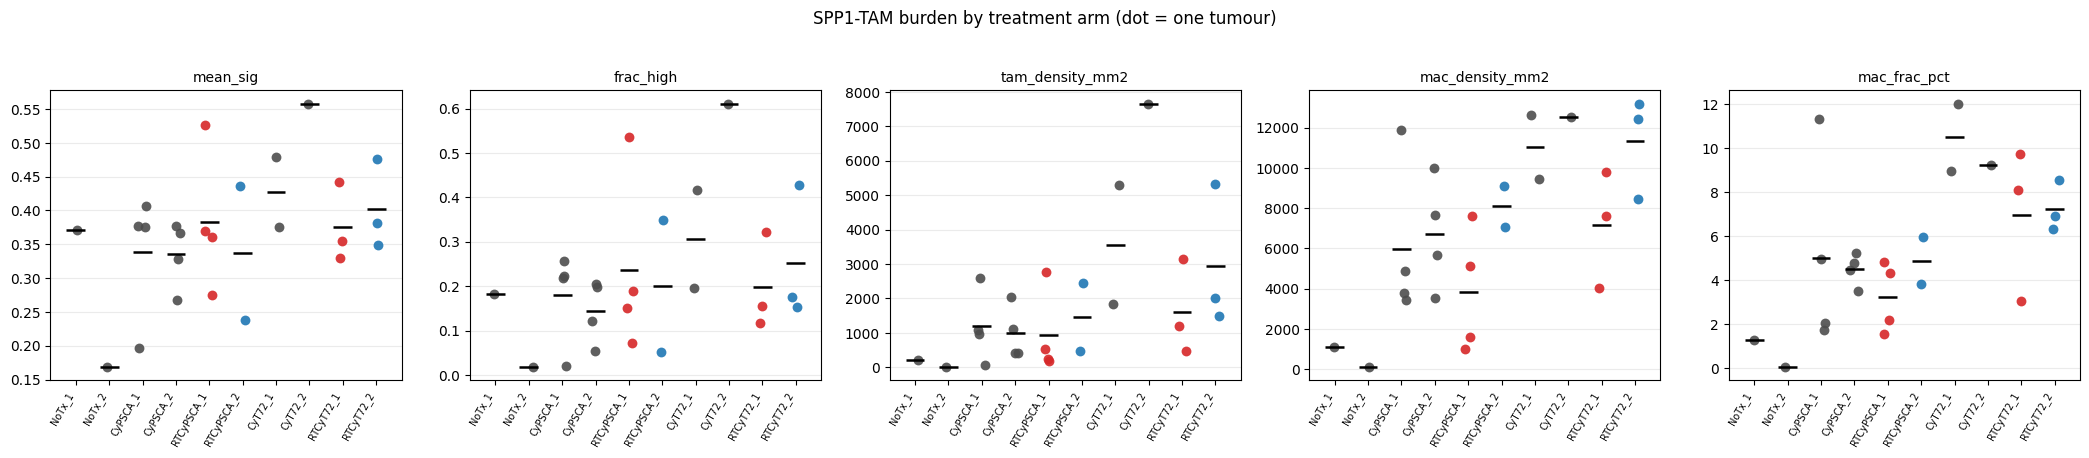

In [5]:
colors = {"no_RT": "#4d4d4d", "RT_direct": "#d62728", "RT_abscopal": "#1f77b4"}
rng = np.random.default_rng(0)
xmap = {g: i for i, g in enumerate(GROUPS)}
fig, axes = plt.subplots(1, len(METRICS), figsize=(4.2 * len(METRICS), 4.4))
for ax, met in zip(np.atleast_1d(axes), METRICS):
    for g in GROUPS:
        s = burden[burden["group"] == g]
        v = s[met].dropna().values
        ax.scatter(xmap[g] + rng.uniform(-0.13, 0.13, len(v)), v, s=50,
                   color=colors.get(s["rt_group"].iloc[0] if len(s) else "no_RT", "k"),
                   alpha=0.9, linewidths=0, zorder=3)
        if len(v):
            ax.hlines(np.mean(v), xmap[g] - 0.28, xmap[g] + 0.28, color="k", lw=1.8, zorder=4)
    ax.set_xticks(list(xmap.values())); ax.set_xticklabels(GROUPS, rotation=60, ha="right", fontsize=7)
    ax.set_title(met, fontsize=10); ax.grid(axis="y", alpha=0.25)
fig.suptitle("SPP1-TAM burden by treatment arm (dot = one tumour)", y=1.03, fontsize=12)
fig.tight_layout(); fig.savefig(FIG_DIR / "spp1tam_burden_by_arm.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)

## 4. Recruitment vs state

Each tumour as a point: macrophage density (recruitment) against mean signature (state). If
treatment moves tissues **down** (lower `mean_sig`) the TAM program is being switched off; if it
moves them **left** (fewer macs) the macrophages are simply not there. The two are different
claims and this plot keeps them separate.

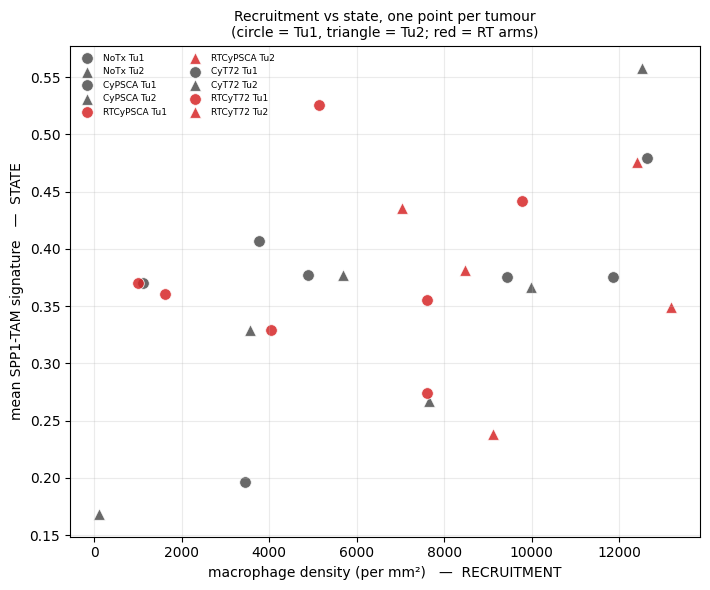

In [6]:
fig, ax = plt.subplots(figsize=(7.2, 6))
mk = {1: "o", 2: "^"}
for cnd in COND_PRESENT:
    s = burden[burden["cond"] == cnd]
    if s.empty:
        continue
    col = "#d62728" if COND_META.get(cnd, {}).get("RT", str(cnd).startswith("RT")) else "#4d4d4d"
    for loc, sub in s.groupby("tumor_loc", observed=True):
        ax.scatter(sub["mac_density_mm2"], sub["mean_sig"], s=70, marker=mk.get(loc, "s"),
                   color=col, alpha=0.85, linewidths=0.6, edgecolors="w",
                   label=f"{cnd} Tu{loc}")
ax.set_xlabel("macrophage density (per mm²)   —  RECRUITMENT")
ax.set_ylabel("mean SPP1-TAM signature   —  STATE")
ax.set_title("Recruitment vs state, one point per tumour\n(circle = Tu1, triangle = Tu2; red = RT arms)", fontsize=10)
ax.legend(fontsize=6.5, ncol=2, frameon=False)
ax.grid(alpha=0.25)
fig.tight_layout(); fig.savefig(FIG_DIR / "spp1tam_recruitment_vs_state.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)

## 5. The abscopal axis — paired within mouse

`<cond>_1_<rep>` and `<cond>_2_<rep>` are the same animal, so Tu2-vs-Tu1 is paired. In the RT
arms Tu1 was irradiated and Tu2 never was. **NoTx is the reference for what the Tu1/Tu2
difference looks like with no treatment at all** — in 05's single-cell data Tu1 and Tu2 were
already asymmetric at baseline, so an unreferenced Tu1-vs-Tu2 gap means nothing.

In [7]:
wide = burden.pivot_table(index=["cond", "rep", "mouse"], columns="tumor_loc",
                          values=METRICS, observed=True)
wide.columns = [f"{a}_Tu{b}" for a, b in wide.columns]
wide = wide.reset_index()
for met in METRICS:
    a, b = f"{met}_Tu1", f"{met}_Tu2"
    if a in wide.columns and b in wide.columns:
        wide[f"{met}_log2_Tu2_over_Tu1"] = np.log2(wide[b] / wide[a]).replace([np.inf, -np.inf], np.nan)
wide.to_csv(OUT_DIR / "spp1tam_paired_within_mouse.csv", index=False)

paired = (wide.groupby("cond", observed=True)
          .agg(n_mice=("mouse", "count"),
               **{f"{m}_n_pairs": (f"{m}_log2_Tu2_over_Tu1", "count") for m in METRICS},
               **{f"{m}_log2": (f"{m}_log2_Tu2_over_Tu1", "mean") for m in METRICS})
          .reindex(COND_PRESENT))
paired.to_csv(OUT_DIR / "spp1tam_paired_summary.csv")
print("=== paired within-mouse log2(Tu2 / Tu1); n_pairs = mice with BOTH tumours ===")
print(paired[["n_mice"] + [f"{m}_n_pairs" for m in METRICS[:2]] + [f"{m}_log2" for m in METRICS]]
      .round(3).to_string())
print("\n  compare every arm against NoTx: NoTx is the untreated Tu1/Tu2 asymmetry baseline.")

=== paired within-mouse log2(Tu2 / Tu1); n_pairs = mice with BOTH tumours ===
          n_mice  mean_sig_n_pairs  frac_high_n_pairs  mean_sig_log2  frac_high_log2  tam_density_mm2_log2  mac_density_mm2_log2  mac_frac_pct_log2
cond                                                                                                                                               
NoTx           2                 0                  0            NaN             NaN                   NaN                   NaN                NaN
CyPSCA         4                 4                  4          0.027           0.006                 0.264                 0.257              0.240
RTCyPSCA       4                 2                  2         -0.236          -0.551                -0.193                 0.358              0.063
CyT72          3                 0                  0            NaN             NaN                   NaN                   NaN                NaN
RTCyT72        3                 3

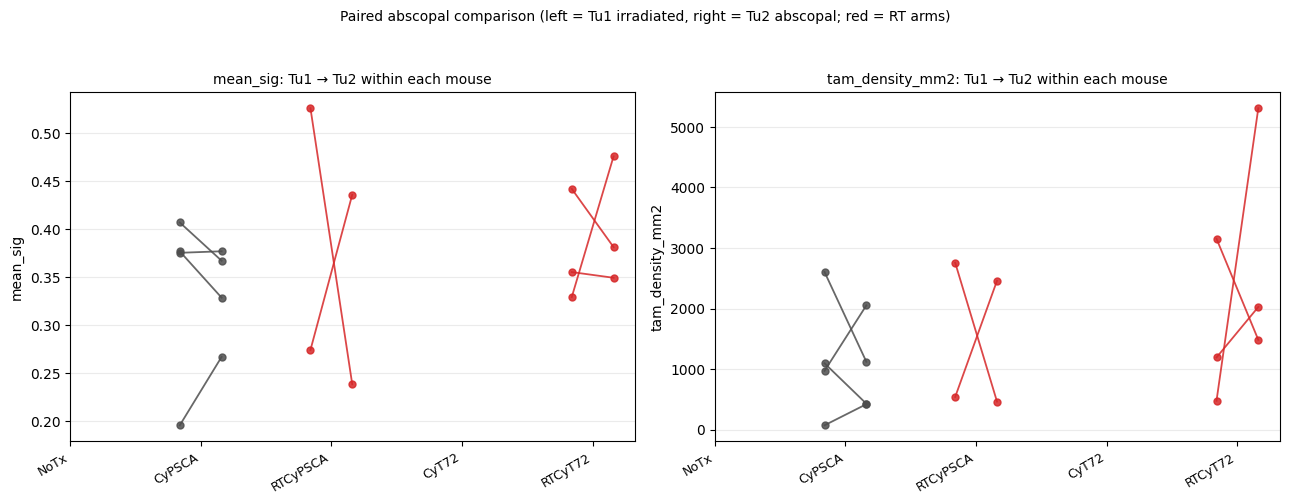

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, met in zip(axes, ["mean_sig", "tam_density_mm2"]):
    a, b = f"{met}_Tu1", f"{met}_Tu2"
    present_conds = [c for c in COND_PRESENT if c in set(wide["cond"])]
    for i, cnd in enumerate(present_conds):
        s = wide[wide["cond"] == cnd]
        col = "#d62728" if COND_META.get(cnd, {}).get("RT", str(cnd).startswith("RT")) else "#4d4d4d"
        for _, r in s.iterrows():
            if np.isfinite(r.get(a, np.nan)) and np.isfinite(r.get(b, np.nan)):
                ax.plot([i - 0.16, i + 0.16], [r[a], r[b]], "-o", color=col, ms=5, lw=1.3, alpha=0.85)
    ax.set_xticks(range(len(present_conds)))
    ax.set_xticklabels(present_conds, rotation=30, ha="right", fontsize=9)
    ax.set_ylabel(met); ax.set_title(f"{met}: Tu1 → Tu2 within each mouse", fontsize=10)
    ax.grid(axis="y", alpha=0.25)
fig.suptitle("Paired abscopal comparison (left = Tu1 irradiated, right = Tu2 abscopal; red = RT arms)",
             y=1.04, fontsize=10)
fig.tight_layout(); fig.savefig(FIG_DIR / "spp1tam_paired_abscopal.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)

## 6. Treatment contrasts, built from the design attributes

The comparisons that isolate one variable at a time. n=2-3 per side, so these are **effect sizes
and consistency** — a p-value at this n cannot go low enough to mean anything and would only
invite over-reading.

In [9]:
def contrast(metric, a_groups, b_groups, name, kind):
    a = burden[burden["group"].isin(a_groups)][metric].dropna().values
    b = burden[burden["group"].isin(b_groups)][metric].dropna().values
    if len(a) < 2 or len(b) < 2:
        return None
    out = {"kind": kind, "contrast": name, "metric": metric, "n_a": len(a), "n_b": len(b),
           "mean_a": a.mean(), "mean_b": b.mean(), "diff": a.mean() - b.mean(),
           "log2_ratio": float(np.log2(a.mean() / b.mean())) if a.mean() > 0 and b.mean() > 0 else np.nan}
    if len(a) >= 3 and len(b) >= 3:
        u = mannwhitneyu(a, b, alternative="two-sided")
        out["cliffs_delta"] = 2 * u.statistic / (len(a) * len(b)) - 1
    return out

# pair each non-RT arm with the RT arm carrying the same CAR-T, so RT is the only variable
RT_PAIRS = [(nr, r, cart)
            for cart in sorted({m["cart"] for m in COND_META.values() if m["cart"] != "none"})
            for nr in [c for c, m in COND_META.items() if not m["RT"] and m["cart"] == cart]
            for r in [c for c, m in COND_META.items() if m["RT"] and m["cart"] == cart]]

specs = []
for nr, r, cart in RT_PAIRS:                                    # RT effect, CAR-T held constant
    specs.append(([f"{r}_2"], [f"{nr}_2"], f"ABSCOPAL  {r}_Tu2 vs {nr}_Tu2  [{cart}]", "abscopal"))
    specs.append(([f"{r}_1"], [f"{nr}_1"], f"DIRECT    {r}_Tu1 vs {nr}_Tu1  [{cart}]", "direct"))
for rt_flag, tag in [(True, "with RT"), (False, "no RT")]:       # CAR-T specificity, RT held constant
    psca = [c for c, m in COND_META.items() if m["RT"] == rt_flag and m["cart"] == "PSCA"]
    tag72 = [c for c, m in COND_META.items() if m["RT"] == rt_flag and m["cart"] == "nonspecific"]
    if psca and tag72:
        specs.append(([f"{psca[0]}_{t}" for t in (1, 2)], [f"{tag72[0]}_{t}" for t in (1, 2)],
                      f"SPECIFICITY  {psca[0]} vs {tag72[0]}  [{tag}]", "specificity"))
notx = [c for c, m in COND_META.items() if m["cart"] == "none"]
if notx:                                                         # every treated arm vs untreated
    for c in [x for x in COND_PRESENT if x not in notx]:
        specs.append(([f"{c}_{t}" for t in (1, 2)], [f"{notx[0]}_{t}" for t in (1, 2)],
                      f"vs UNTREATED  {c} vs {notx[0]}", "vs_untreated"))

rows = [r for met in METRICS for a, b, nm, kind in specs if (r := contrast(met, a, b, nm, kind))]
contrasts = pd.DataFrame(rows)
contrasts.to_csv(OUT_DIR / "spp1tam_treatment_contrasts.csv", index=False)
for kind in ["abscopal", "direct", "specificity", "vs_untreated"]:
    sub = contrasts[(contrasts["kind"] == kind) & (contrasts["metric"].isin(["mean_sig", "tam_density_mm2"]))]
    if sub.empty:
        continue
    print(f"\n=== {kind.upper()} ===")
    print(sub[["contrast", "metric", "n_a", "n_b", "mean_a", "mean_b", "log2_ratio"]]
          .round(3).to_string(index=False))


=== ABSCOPAL ===
                                    contrast          metric  n_a  n_b   mean_a   mean_b  log2_ratio
ABSCOPAL  RTCyPSCA_Tu2 vs CyPSCA_Tu2  [PSCA]        mean_sig    2    4    0.337    0.335       0.010
ABSCOPAL  RTCyPSCA_Tu2 vs CyPSCA_Tu2  [PSCA] tam_density_mm2    2    4 1461.636 1005.942       0.539

=== DIRECT ===
                                    contrast          metric  n_a  n_b  mean_a   mean_b  log2_ratio
DIRECT    RTCyPSCA_Tu1 vs CyPSCA_Tu1  [PSCA]        mean_sig    4    4   0.383    0.339       0.175
DIRECT    RTCyPSCA_Tu1 vs CyPSCA_Tu1  [PSCA] tam_density_mm2    4    4 932.331 1185.917      -0.347

=== VS_UNTREATED ===
                      contrast          metric  n_a  n_b   mean_a  mean_b  log2_ratio
  vs UNTREATED  CyPSCA vs NoTx        mean_sig    8    2    0.337   0.269       0.323
vs UNTREATED  RTCyPSCA vs NoTx        mean_sig    6    2    0.368   0.269       0.448
   vs UNTREATED  CyT72 vs NoTx        mean_sig    3    2    0.471   0.269       0.8

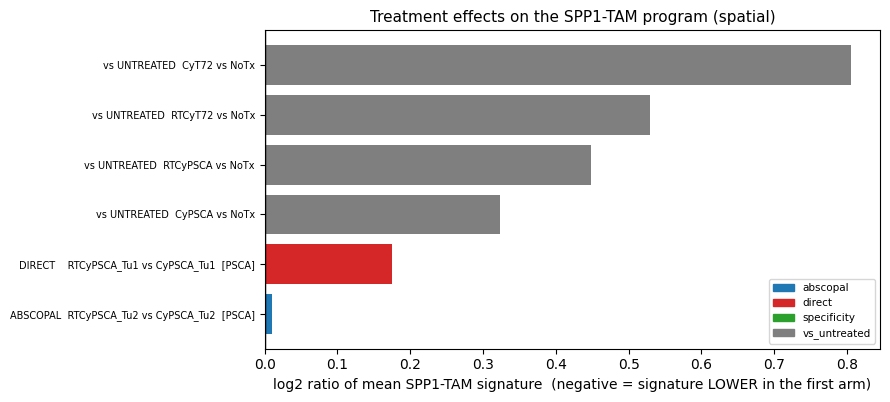

In [10]:
plot = contrasts[contrasts["metric"] == "mean_sig"].dropna(subset=["log2_ratio"]).sort_values("log2_ratio")
if not plot.empty:
    kind_c = {"abscopal": "#1f77b4", "direct": "#d62728", "specificity": "#2ca02c", "vs_untreated": "#7f7f7f"}
    fig, ax = plt.subplots(figsize=(9, 0.42 * len(plot) + 1.6))
    ax.barh(range(len(plot)), plot["log2_ratio"].values,
            color=[kind_c.get(k, "#999") for k in plot["kind"]])
    ax.axvline(0, color="k", lw=1)
    ax.set_yticks(range(len(plot))); ax.set_yticklabels(plot["contrast"], fontsize=7)
    ax.set_xlabel("log2 ratio of mean SPP1-TAM signature  (negative = signature LOWER in the first arm)")
    ax.set_title("Treatment effects on the SPP1-TAM program (spatial)", fontsize=11)
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color=c, label=k) for k, c in kind_c.items()], fontsize=7.5, loc="lower right")
    fig.tight_layout(); fig.savefig(FIG_DIR / "spp1tam_treatment_contrasts.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close(fig)

## 7. Does the **niche coupling** itself change with treatment?

Reads 02's per-tissue niche correlations. 02 aggregates them by `rt_group`; here they are
aggregated by full arm, so the PSCA-vs-TAG72 axis is visible. The question: is the SPP1-TAM
program still tied to hypoxia / oxidised-lipid neighbourhoods under treatment, or is the
coupling itself broken?

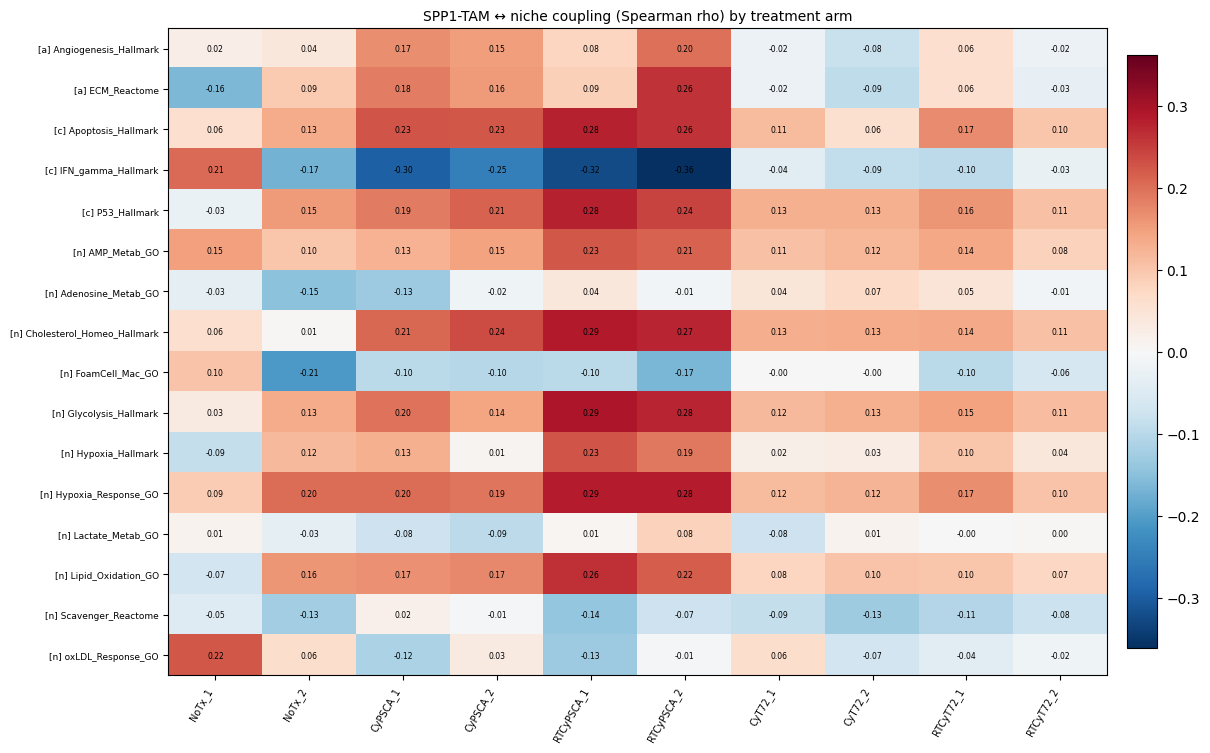

niche tier means by arm (positive = SPP1-TAM macs sit in that niche):
group
NoTx_1        0.040
NoTx_2        0.024
CyPSCA_1      0.057
CyPSCA_2      0.065
RTCyPSCA_1    0.115
RTCyPSCA_2    0.117
CyT72_1       0.047
CyT72_2       0.047
RTCyT72_1     0.054
RTCyT72_2     0.033


In [11]:
f_niche = OUT_DIR / "spp1tam_niche_correlation_long.csv"
if f_niche.exists():
    nl = pd.read_csv(f_niche)
    nl[["cond2", "loc2", "rep2"]] = nl["tissue"].apply(lambda t: pd.Series(parse_tissue(t)))
    nl["group"] = nl["cond2"] + "_" + nl["loc2"].astype(str)
    piv = nl.pivot_table(index=["tier", "pathway"], columns="group", values="rho", observed=True)
    piv = piv.reindex(columns=[g for g in GROUPS if g in piv.columns])
    piv.to_csv(OUT_DIR / "spp1tam_niche_correlation_by_arm.csv")
    data = piv.values.astype(float)
    vmax = np.nanmax(np.abs(data)) if np.isfinite(data).any() else 1.0
    fig, ax = plt.subplots(figsize=(0.72 * data.shape[1] + 5, 0.34 * data.shape[0] + 2.2))
    im = ax.imshow(data, cmap="RdBu_r", norm=TwoSlopeNorm(0, -vmax, vmax), aspect="auto")
    ax.set_xticks(range(data.shape[1])); ax.set_xticklabels(piv.columns, rotation=60, ha="right", fontsize=7)
    ax.set_yticks(range(data.shape[0]))
    ax.set_yticklabels([f"[{t[0][0]}] {t[1]}" for t in piv.index], fontsize=6.5)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            if np.isfinite(data[i, j]):
                ax.text(j, i, f"{data[i,j]:.2f}", ha="center", va="center", fontsize=5.5)
    ax.set_title("SPP1-TAM ↔ niche coupling (Spearman rho) by treatment arm", fontsize=10)
    fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    fig.tight_layout(); fig.savefig(FIG_DIR / "spp1tam_niche_by_arm.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close(fig)
    print("niche tier means by arm (positive = SPP1-TAM macs sit in that niche):")
    print(nl[nl["tier"] == "niche"].groupby("group", observed=True)["rho"].mean().reindex(
        [g for g in GROUPS]).round(3).to_string())
else:
    print(f"not found: {f_niche.name} — run 02 first for this section.")

## 8. Does the **neighbourhood** around SPP1-TAMs change with treatment?

Reads 03's per-tissue neighbourhood table. The headline cell type is **CD8_T**: the PDF predicts
SPP1-TAMs exclude CD8 T cells, and whether treatment *relieves* that exclusion is the most
therapeutically meaningful thing in this whole analysis.

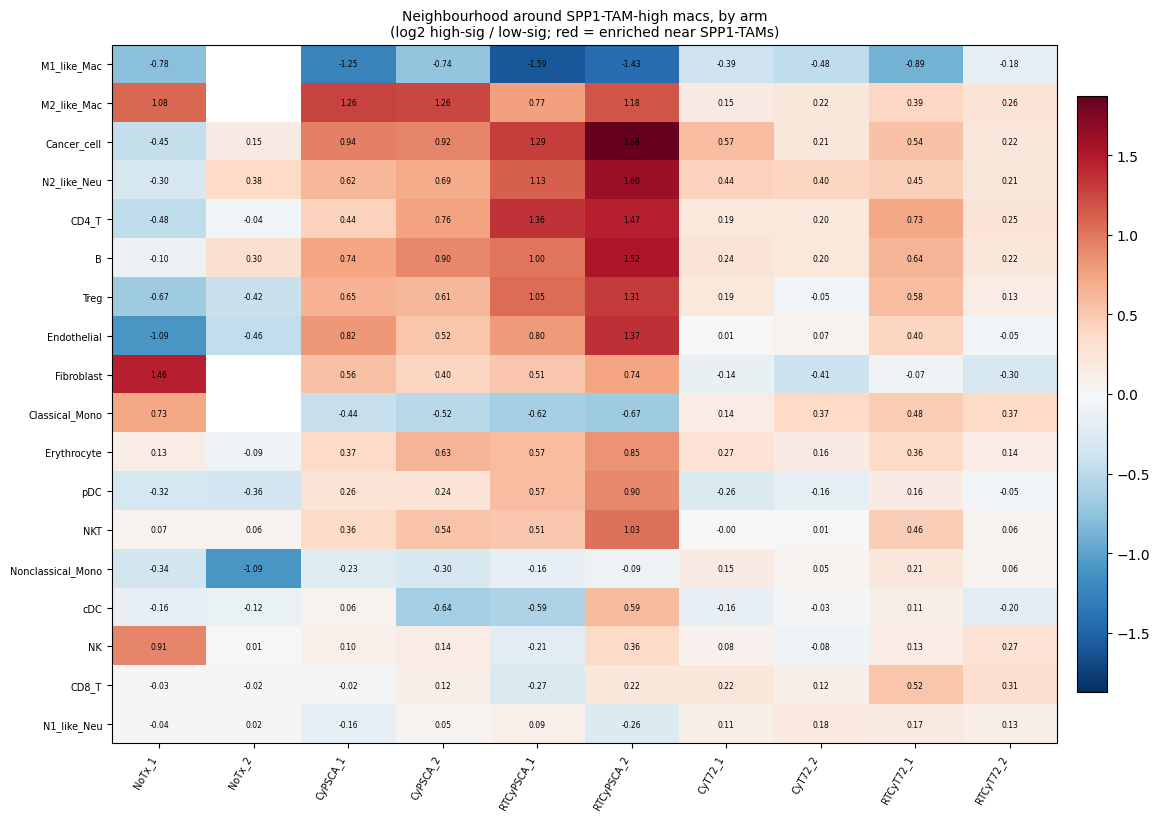


CD8_T around SPP1-TAM-high macs (log2 vs low-sig macs), by arm:
group
NoTx_1       -0.027
NoTx_2       -0.016
CyPSCA_1     -0.021
CyPSCA_2      0.124
RTCyPSCA_1   -0.266
RTCyPSCA_2    0.219
CyT72_1       0.218
CyT72_2       0.118
RTCyT72_1     0.516
RTCyT72_2     0.315
  negative = CD8 EXCLUDED from the SPP1-TAM neighbourhood.
  If it is negative in NoTx and rises toward 0 with treatment, therapy is
  relieving the exclusion — the most quotable result available here.

Cancer_cell around SPP1-TAM-high macs (log2 vs low-sig macs), by arm:
group
NoTx_1       -0.449
NoTx_2        0.148
CyPSCA_1      0.940
CyPSCA_2      0.919
RTCyPSCA_1    1.294
RTCyPSCA_2    1.876
CyT72_1       0.575
CyT72_2       0.213
RTCyT72_1     0.544
RTCyT72_2     0.216

Fibroblast around SPP1-TAM-high macs (log2 vs low-sig macs), by arm:
group
NoTx_1        1.458
NoTx_2          NaN
CyPSCA_1      0.556
CyPSCA_2      0.402
RTCyPSCA_1    0.509
RTCyPSCA_2    0.744
CyT72_1      -0.137
CyT72_2      -0.407
RTCyT72_1    -

In [12]:
f_nb = OUT_DIR / "spp1tam_celltype_neighborhood_long.csv"
if f_nb.exists():
    nb = pd.read_csv(f_nb)
    nb[["cond2", "loc2", "rep2"]] = nb["tissue"].apply(lambda t: pd.Series(parse_tissue(t)))
    nb["group"] = nb["cond2"] + "_" + nb["loc2"].astype(str)
    piv = nb.pivot_table(index="celltype", columns="group", values="log2_ratio", observed=True)
    piv = piv.reindex(columns=[g for g in GROUPS if g in piv.columns])
    piv = piv.loc[piv.abs().mean(axis=1).sort_values(ascending=False).index]
    piv.to_csv(OUT_DIR / "spp1tam_neighborhood_by_arm.csv")
    data = piv.values.astype(float)
    vmax = np.nanmax(np.abs(data)) if np.isfinite(data).any() else 1.0
    fig, ax = plt.subplots(figsize=(0.72 * data.shape[1] + 4.5, 0.34 * data.shape[0] + 2.2))
    im = ax.imshow(data, cmap="RdBu_r", norm=TwoSlopeNorm(0, -vmax, vmax), aspect="auto")
    ax.set_xticks(range(data.shape[1])); ax.set_xticklabels(piv.columns, rotation=60, ha="right", fontsize=7)
    ax.set_yticks(range(data.shape[0])); ax.set_yticklabels(piv.index, fontsize=7)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            if np.isfinite(data[i, j]):
                ax.text(j, i, f"{data[i,j]:.2f}", ha="center", va="center", fontsize=5.5)
    ax.set_title("Neighbourhood around SPP1-TAM-high macs, by arm\n"
                 "(log2 high-sig / low-sig; red = enriched near SPP1-TAMs)", fontsize=10)
    fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    fig.tight_layout(); fig.savefig(FIG_DIR / "spp1tam_neighborhood_by_arm.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close(fig)
    for target in ["CD8_T", "Cancer_cell", "Fibroblast"]:
        if target in set(nb["celltype"]):
            s = nb[nb["celltype"] == target].groupby("group", observed=True)["log2_ratio"].mean()
            print(f"\n{target} around SPP1-TAM-high macs (log2 vs low-sig macs), by arm:")
            print(s.reindex([g for g in GROUPS if g in s.index]).round(3).to_string())
            if target == "CD8_T":
                print("  negative = CD8 EXCLUDED from the SPP1-TAM neighbourhood.")
                print("  If it is negative in NoTx and rises toward 0 with treatment, therapy is")
                print("  relieving the exclusion — the most quotable result available here.")
else:
    print(f"not found: {f_nb.name} — run 03 first for this section.")

## 9. Summary

In [13]:
print(f"""
==================== SUMMARY — report these back ====================
Tissues / mice : {len(burden)} / {burden['mouse'].nunique()}   arms: {COND_PRESENT}
Signature      : {len(present)}/{len(sig_genes)} genes | SPP1-TAM-high cut = {SIG_CUT:.3f} (top {int((1-SIG_HIGH_Q)*100)}% of macs)

Burden by arm (mean across tissues):
{by_group[['n_tissues','mean_sig','frac_high','tam_density_mm2','mac_density_mm2']].round(3).to_string()}

Paired within-mouse log2(Tu2/Tu1):
{paired[[f'{m}_log2' for m in ['mean_sig','tam_density_mm2']]].round(3).to_string()}

HOW TO READ THIS
 1. §4 recruitment vs state - the decomposition that matters. mean_sig DOWN with mac_density flat
    = the TAM program is switched off (reprogramming). mac_density DOWN with mean_sig flat
    = macrophages simply absent (trafficking). They imply different mechanisms and different
    follow-ups; 05 §5 found the single-cell answer was per-cell state, so watch whether space agrees.
 2. §5 abscopal - always read each arm against NoTx. Tu1 and Tu2 differ at baseline (05), so a raw
    Tu1-vs-Tu2 gap is not by itself an abscopal effect.
 3. §6 SPECIFICITY (PSCA vs TAG72) is the contrast 02-04 could not make. In single-cell it was the
    cleanest signal (~40% lower Spp1, consistent across 4 comparisons). If it reproduces spatially,
    that is a CAR-T-attributable effect on the TAM compartment, not a generic treatment effect.
 4. §8 CD8_T is the therapeutic headline: exclusion in NoTx that relaxes under treatment.

CAVEATS: n=2-3 tissues per arm, so effect size and sign-consistency only - no p-values. Convex-hull
area over-estimates for concave/fragmented sections, which inflates area and deflates density;
mean_sig and frac_high are area-free and unaffected by that.
=====================================================================
""")


==================== SUMMARY — report these back ====================
Tissues / mice : 25 / 16   arms: ['NoTx', 'CyPSCA', 'RTCyPSCA', 'CyT72', 'RTCyT72']
Signature      : 48/50 genes | SPP1-TAM-high cut = 0.505 (top 25% of macs)

Burden by arm (mean across tissues):
            n_tissues  mean_sig  frac_high  tam_density_mm2  mac_density_mm2
group                                                                       
NoTx_1              1     0.371      0.183          205.489         1125.386
NoTx_2              1     0.168      0.018            1.755          100.009
CyPSCA_1            4     0.339      0.180         1185.917         5996.099
CyPSCA_2            4     0.335      0.145         1005.942         6719.542
RTCyPSCA_1          4     0.383      0.237          932.331         3838.956
RTCyPSCA_2          2     0.337      0.200         1461.636         8085.330
CyT72_1             2     0.427      0.306         3561.186        11042.107
CyT72_2             1     0.558      0.